## User-Based + Item-Based

In [1]:
import ast
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import MinMaxScaler
from rapidfuzz import process, fuzz

### Load Steam Dataset

In [2]:
# Подгрузим Steam Dataset, возьмем только записи тех кто уже поиграл в игру.

steam_raw = pd.read_csv('../SteamDataset200K/steam-200k.csv', header=None, names=['user_id', 'game', 'behavior', 'hours', 'zero'])

df = steam_raw[steam_raw['behavior'] == 'play'].copy()
df = df[['user_id', 'game', 'hours']].reset_index(drop=True)

df.head()

,user_id,game,hours
0,151603712,The Elder Scrolls V Skyrim,273.0
1,151603712,Fallout 4,87.0
2,151603712,Spore,14.9
3,151603712,Fallout New Vegas,12.1
4,151603712,Left 4 Dead 2,8.9


In [3]:
# Конвертируем игровые часы в рейтинг, чтобы метрика стала более читаемой.
# Масштабируем логарифмически.

def hours_to_rating(hours_series):
    log_h = np.log1p(hours_series)
    scaler = MinMaxScaler(feature_range=(1, 10))
    ratings = scaler.fit_transform(log_h.values.reshape(-1, 1)).flatten()

    return np.round(ratings, 2)


df['rating'] = hours_to_rating(df['hours'])

df.head(10)

,user_id,game,hours,rating
0,151603712,The Elder Scrolls V Skyrim,273.0,6.35
1,151603712,Fallout 4,87.0,5.25
2,151603712,Spore,14.9,3.59
3,151603712,Fallout New Vegas,12.1,3.40
4,151603712,Left 4 Dead 2,8.9,3.13
5,151603712,HuniePop,8.5,3.09
6,151603712,Path of Exile,8.1,3.05
7,151603712,Poly Bridge,7.5,2.98
8,151603712,Left 4 Dead,3.3,2.32
9,151603712,Team Fortress 2,2.8,2.20


In [4]:
# Делаем датасет менее разряженным (это может повлечь проблемы: непопулярные игры не будут рекомендоваться, но мы подумаем над этим позже)

MIN_GAMES_PER_USER = 3
MIN_USERS_PER_GAME = 5

user_counts = df.groupby('user_id')['game'].count()
game_counts = df.groupby('game')['user_id'].count()

active_users = user_counts[user_counts >= MIN_GAMES_PER_USER].index
popular_games = game_counts[game_counts >= MIN_USERS_PER_GAME].index

df_filtered = df[df['user_id'].isin(active_users) & df['game'].isin(popular_games)]

user_item_matrix = df_filtered.pivot_table(
    index='user_id',
    columns='game',
    values='rating',
    aggfunc='mean'
).fillna(0)

user_item_matrix

game,1... 2... 3... KICK IT! (Drop That Beat Like an Ugly Baby),100% Orange Juice,12 Labours of Hercules,12 Labours of Hercules II The Cretan Bull,140,3DMark,404Sight,60 Seconds!,7 Days to Die,8BitBoy,...,Zeno Clash,Zombie Army Trilogy,Zombie Driver,Zombie Panic Source,Zombies Monsters Robots,ibb & obb,resident evil 4 / biohazard 4,sZone-Online,the static speaks my name,theHunter
user_id,,,,,,,,,,,,,,,,,,,,,
5250,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
76767,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
86540,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
229911,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
298950,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.55,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
306547522,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
306971738,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
308695132,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### User-Based

In [5]:
def user_based_rec(user_id, user_item_matrix, n_neighbors=20, top_n=20):
    if user_id not in user_item_matrix.index:
        return None

    sim_matrix = cosine_similarity(user_item_matrix.values)
    sim_df = pd.DataFrame(sim_matrix, index=user_item_matrix.index, columns=user_item_matrix.index)

    user_sim = sim_df[user_id].drop(user_id).sort_values(ascending=False)
    neighbors = user_sim.head(n_neighbors)

    user_games = user_item_matrix.loc[user_id]
    unplayed = user_games[user_games == 0].index

    neighbor_ratings = user_item_matrix.loc[neighbors.index, unplayed]
    weights = neighbors.values.reshape(-1, 1)

    weighted_sum = (neighbor_ratings * weights).sum(axis=0)
    weight_total = (neighbor_ratings > 0).astype(int).T.dot(weights.flatten())
    weight_total = weight_total.replace(0, np.nan)

    predicted = (weighted_sum / weight_total).dropna().sort_values(ascending=False)

    result = predicted.head(top_n).reset_index()
    result.columns = ['game', 'ub_score']

    return result


sample_user = user_item_matrix.index[0]
games_sample_user = user_item_matrix.loc[sample_user]
played = games_sample_user[games_sample_user != 0]
ub_recs = user_based_rec(sample_user, user_item_matrix)

played, ub_recs

(game
 Alien Swarm                 2.63
 Cities Skylines             5.74
 Deus Ex Human Revolution    4.93
 Dota 2                      1.08
 Portal 2                    3.51
 Team Fortress 2             1.48
 Name: 5250, dtype: float64,
                                            game  ub_score
 0                         Counter-Strike Source  6.550000
 1                          Farming Simulator 15  5.250000
 2                          Realm of the Mad God  5.110000
 3                                Clicker Heroes  5.020000
 4                            Half-Life 2 Update  4.970000
 5                                   Garry's Mod  4.960000
 6                            Tabletop Simulator  4.860000
 7               Never Alone (Kisima Ingitchuna)  4.810000
 8                                    Watch_Dogs  4.780000
 9   Grand Theft Auto Episodes from Liberty City  4.530000
 10                                  Train Fever  4.490000
 11      Call of Duty Black Ops II - Multiplayer  4.4

### Load PlayMyData

In [6]:
pc = pd.read_csv('../PlayMyData/all_games_PC.csv')
ps = pd.read_csv('../PlayMyData/all_games_PlayStation.csv')
genres_df = pd.read_csv('../PlayMyData/genres.csv')

games_df = pd.concat([pc, ps], ignore_index=True).drop_duplicates(subset='id').reset_index(drop=True)

games_df['rating'] = pd.to_numeric(games_df['rating'], errors='coerce')

games_df.head()

,genres,id,name,platforms,summary,storyline,rating,main,extra,completionist,review_score,review_count,people_polled
0,[5],274203,Short 'n Quick,[6],this is a techstyled map taking place in a war...,Missing,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,[5],256819,Caverns of Darkness,[6],The final rift was closed and the Hell War was...,Missing,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,"[26, 31]",232860,"Nu, pogodi! Vypusk 1: Pogonya",[6],The wolf decides to take revenge on the Hare f...,Missing,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,"[12, 15, 16]",228979,Power Dolls 5,[6],The fifth entry in Kogado Studios allfemale me...,Missing,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,[2],225648,Kapsyljakt med Anki & Pytte,[6],A pointandclick game based on the Swedish chil...,Missing,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
def parse_genres(value):
    if not isinstance(value, str):
        return []
    value = value.strip()
    if value == '' or value == 'Missing':
        return []
    try:
        result = ast.literal_eval(value)

        return result if isinstance(result, list) else []
    except Exception:
        return []


games_df['genres_list'] = games_df['genres'].apply(parse_genres)

#One-hot encoding
all_genre_ids = genres_df['genre_id'].tolist()
for gid in all_genre_ids:
    games_df[f'genre_{gid}'] = games_df['genres_list'].apply(lambda x: int(gid in x))

num_features = ['rating', 'review_score', 'main', 'extra', 'completionist']
for column in num_features:
    games_df[column] = pd.to_numeric(games_df[column], errors='coerce')
    games_df[column] = games_df[column].fillna(games_df[column].median())
    max_value = games_df[column].max()

    if max_value > 0:
        games_df[column] = games_df[column] / max_value

games_df.head(10)

,genres,id,name,platforms,summary,storyline,rating,main,extra,completionist,...,genre_26,genre_25,genre_30,genre_31,genre_33,genre_34,genre_32,genre_35,genre_36,genre_2
0,[5],274203,Short 'n Quick,[6],this is a techstyled map taking place in a war...,Missing,0.7,0.000309,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
1,[5],256819,Caverns of Darkness,[6],The final rift was closed and the Hell War was...,Missing,0.7,0.000309,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
2,"[26, 31]",232860,"Nu, pogodi! Vypusk 1: Pogonya",[6],The wolf decides to take revenge on the Hare f...,Missing,0.7,0.000309,0.0,0.0,...,1,0,0,1,0,0,0,0,0,0
3,"[12, 15, 16]",228979,Power Dolls 5,[6],The fifth entry in Kogado Studios allfemale me...,Missing,0.7,0.000309,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
4,[2],225648,Kapsyljakt med Anki & Pytte,[6],A pointandclick game based on the Swedish chil...,Missing,0.7,0.000309,0.0,0.0,...,0,0,0,0,0,0,0,0,0,1
5,[10],204650,Rage Rally,[6],Missing,Missing,0.7,0.000000,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
6,[34],194713,Ripple: Blue Seal he Youkoso,[6],Main character loses a job and applies for an ...,Missing,0.7,0.000309,0.0,0.0,...,0,0,0,0,0,1,0,0,0,0
7,[31],73345,The Mystery of the Nautilus,[6],This adventure game was inspired by the Jules ...,The story begins aboard the USS Shark a resear...,0.7,0.000309,0.0,0.0,...,0,0,0,1,0,0,0,0,0,0
8,"[2, 31]",71917,JumpStart: Animal Adventures,"[6, 14]",Educational game for teaching kids about wild ...,Missing,0.7,0.000309,0.0,0.0,...,0,0,0,1,0,0,0,0,0,1
9,Missing,61935,Farland Symphony,[6],A spinoff title in the Farland Story RPG franc...,Missing,0.7,0.000309,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0


In [8]:
# Решаем проблему исключения нишевых игр
# Для Item-Based расширяем матрицу сходства, игры из Steam датасета используем как сиды (игры юзера), а при нахождении похожих игр, берем все из PlayMyData (85k).
# Это позволит рекомендовать нишевые игры, даже если их вообще не было в датасете Steam.

steam_games_names = set(user_item_matrix.columns)

genre_columns = [f'genre_{gid}' for gid in all_genre_ids]
num_columns = ['rating', 'review_score', 'main', 'extra', 'completionist']
feature_columns = genre_columns + num_columns

GENRE_WEIGHT = 3.0
NUMERIC_WEIGHT = 1.5

all_content_games = games_df.copy().drop_duplicates(subset='name').set_index('name')
feature_matrix_all = all_content_games[feature_columns].fillna(0).values.copy().astype(float)

n_genre = len(genre_columns)
feature_matrix_all[:, :n_genre] *= GENRE_WEIGHT
feature_matrix_all[:, :n_genre] *= NUMERIC_WEIGHT

steam_in_playmydata = [g for g in steam_games_names if g in all_content_games.index]
steam_index = [all_content_games.index.get_loc(g) for g in steam_in_playmydata]
steam_vectors = feature_matrix_all[steam_index]

item_sim_matrix = cosine_similarity(feature_matrix_all, steam_vectors)
item_sim_df = pd.DataFrame(
    item_sim_matrix,
    index=all_content_games.index,
    columns=steam_in_playmydata
)

item_sim_df

,Deponia,Prime World,LEGO Worlds,Anno 1404,Risen,Max Payne 3,Worms Reloaded,Relic Hunters Zero,Gnomoria,Starpoint Gemini 2,...,Football Manager 2010,Gang Beasts,Receiver,Frozen Synapse,Grand Theft Auto,Elsword,Cogs,F1 2013,Sine Mora,F1 2010
name,,,,,,,,,,,,,,,,,,,,,
Short 'n Quick,0.022204,0.024128,0.028621,0.023683,0.032569,0.998246,0.030846,0.507982,0.024724,0.025140,...,0.027882,0.029966,0.584622,0.019807,0.586443,0.027981,0.029678,0.022296,0.586019,0.026173
Caverns of Darkness,0.022204,0.024128,0.028621,0.023683,0.032569,0.998246,0.030846,0.507982,0.024724,0.025140,...,0.027882,0.029966,0.584622,0.019807,0.586443,0.027981,0.029678,0.022296,0.586019,0.026173
"Nu, pogodi! Vypusk 1: Pogonya",0.363673,0.017224,0.510184,0.364407,0.023250,0.034080,0.022020,0.014385,0.017649,0.017947,...,0.019904,0.021391,0.015602,0.014139,0.418638,0.509947,0.021186,0.015916,0.017204,0.018684
Power Dolls 5,0.012983,0.818899,0.016736,0.298494,0.418836,0.027915,0.418465,0.011783,0.583386,0.671477,...,0.343957,0.017522,0.012780,0.521953,0.014427,0.417708,0.017354,0.297935,0.014092,0.015305
Kapsyljakt med Anki & Pytte,0.509446,0.024128,0.028621,0.023683,0.032569,0.047740,0.030846,0.020152,0.024724,0.025140,...,0.027882,0.029966,0.021856,0.019807,0.024673,0.027981,0.029678,0.022296,0.024100,0.026173
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Magical Drop 3,0.509612,0.030604,0.713875,0.030946,0.042594,0.062423,0.040170,0.026231,0.032161,0.032468,...,0.036397,0.039084,0.028341,0.456239,0.032020,0.036352,0.714663,0.029073,0.031594,0.034160
Tenchu 2: Birth of the Stealth Assassins,0.509723,0.029773,0.714201,0.511151,0.041171,0.060338,0.038862,0.025379,0.031120,0.031468,...,0.035213,0.037798,0.027442,0.024939,0.586355,0.713728,0.037285,0.028121,0.030521,0.033034
Dragon Warrior VII,0.364329,0.509280,0.511028,0.365149,0.512313,0.036885,0.023887,0.015609,0.019158,0.419704,...,0.021563,0.023185,0.016965,0.015345,0.419410,0.999790,0.023028,0.017253,0.018593,0.020243


In [9]:
FUZZY_THRESHOLD = 93

BLACKLIST = {'Besiege', 'Jamestown', 'Color Symphony', 'Goat Simulator', 'Borderlands 2 RU', 'Ragnarok', 'Knights of Pen and Paper +1'}

playmydata_names = all_content_games.index.tolist()
unmatched = steam_games_names - set(all_content_games.index)

fuzzy_map = {}
for steam_name in unmatched:
    if steam_name in BLACKLIST:
        continue

    match, score, _ = process.extractOne(steam_name,
                                         playmydata_names,
                                         scorer=fuzz.token_sort_ratio)
    if score >= FUZZY_THRESHOLD:
        fuzzy_map[steam_name] = match

fuzzy_rows = []
for steam_name, playmydata_name in fuzzy_map.items():
    if playmydata_name in all_content_games.index:
        row = all_content_games.loc[playmydata_name].copy()
        row.name = steam_name
        fuzzy_rows.append(row)

if fuzzy_rows:
    fuzzy_df = pd.DataFrame(fuzzy_rows)
    all_content_games = pd.concat([all_content_games, fuzzy_df])

len(all_content_games)

84030

### Item-Based

In [10]:
def item_based_rec(user_id, user_item_matrix, item_sim_df, n_neighbors=20, top_n=20, sim_threshold=0.7, min_seeds=2):
    if user_id not in user_item_matrix.index:
        return None

    user_games = user_item_matrix.loc[user_id]
    played = user_games[user_games != 0]
    played_known = played[played.index.isin(item_sim_df.columns)]

    if len(played_known) == 0:
        return None

    already_played = set(played.index)
    candidates = [g for g in item_sim_df.index if g not in already_played]

    sim_block = item_sim_df.loc[candidates, played_known.index].values.copy()

    for i in range(len(sim_block)):
        row = sim_block[i]
        threshold_idx = np.argsort(row)[:-n_neighbors]
        row[threshold_idx] = 0

    seeds_above_threshold = (sim_block >= sim_threshold).sum(axis=1)
    mask = seeds_above_threshold >= min_seeds

    sim_block = sim_block[mask]
    filtered_candidates = [c for c, m in zip(candidates, mask) if m]

    ratings = played_known.values
    weighted_sum = sim_block.dot(ratings)
    weight_total = sim_block.sum(axis=1)
    weight_total[weight_total == 0] = np.nan

    result = pd.Series(weighted_sum, index=filtered_candidates).dropna()
    result = result.sort_values(ascending=False).head(top_n).reset_index()
    result.columns = ['game', 'ib_score']

    return result


sample_user = user_item_matrix.index[0]
games_sample_user = user_item_matrix.loc[sample_user]
played = games_sample_user[games_sample_user != 0]

ib_recs = item_based_rec(sample_user, user_item_matrix, item_sim_df)

played, ib_recs

(game
 Alien Swarm                 2.63
 Cities Skylines             5.74
 Deus Ex Human Revolution    4.93
 Dota 2                      1.08
 Portal 2                    3.51
 Team Fortress 2             1.48
 Name: 5250, dtype: float64,
                                                game  ib_score
 0                 Halo: The Master Chief Collection  5.958774
 1                                   Resident Evil 4  5.958244
 2                                       Half-Life 2  5.958231
 3                                    Counter-Strike  5.958055
 4                                      Doom Eternal  5.957872
 5                                 The Ultimate Doom  5.957798
 6                                 Unreal Tournament  5.957736
 7                                          Returnal  5.957657
 8   No One Lives Forever 2: A Spy in H.A.R.M.'s Way  5.957594
 9                                            Halo 3  5.957589
 10         Medal of Honor: Allied Assault War Chest  5.957574
 11  

### Hybrid Model (User-Based + Item-Based)

In [11]:
# alpha - вес User-Based оценки
# beta - вес Item-Based оценки
# boost_factor - множитель для игр из пересечения User-Based и Item-Based
# discount_factor - множитель для игр только из одного

def hybrid_rec(user_id, user_item_matrix, item_sim_df, n_neighbours=20, top_n=20,
               alpha=0.8, beta=0.2, boost_factor=1.3, discount_factor=0.7):
    ub = user_based_rec(user_id, user_item_matrix, n_neighbours, top_n)
    ib = item_based_rec(user_id, user_item_matrix, item_sim_df, n_neighbours, top_n)

    if ub is None or ib is None:
        return None

    def normalize(series):
        mn, mx = series.min(), series.max()

        return (series - mn) / (mx - mn + 1e-9)

    ub['ub_score'] = normalize(ub['ub_score'])
    ib['ib_score'] = normalize(ib['ib_score'])

    merged = pd.merge(ub, ib, on='game', how='outer')

    both = merged.dropna(subset=['ub_score', 'ib_score']).copy()
    both['final_score'] = (alpha * both['ub_score'] + beta * both['ib_score']) * boost_factor

    only_ub = merged[merged['ib_score'].isna()].copy()
    only_ub['final_score'] = only_ub['ub_score'] * discount_factor

    only_ib = merged[merged['ub_score'].isna()].copy()
    only_ib['final_score'] = only_ib['ib_score'] * discount_factor

    result = pd.concat([both, only_ub, only_ib], ignore_index=True)
    result = result[['game', 'final_score']].sort_values('final_score', ascending=False).head(top_n).reset_index(drop=True)

    result.index += 1

    return result


sample_user = user_item_matrix.index[0]
games_sample_user = user_item_matrix.loc[sample_user]
played = games_sample_user[games_sample_user != 0]

hybrid_recs = hybrid_rec(sample_user, user_item_matrix, item_sim_df)

played, hybrid_recs

(game
 Alien Swarm                 2.63
 Cities Skylines             5.74
 Deus Ex Human Revolution    4.93
 Dota 2                      1.08
 Portal 2                    3.51
 Team Fortress 2             1.48
 Name: 5250, dtype: float64,
                                                game  final_score
 1                             Counter-Strike Source     0.700000
 2                 Halo: The Master Chief Collection     0.700000
 3                                   Resident Evil 4     0.478233
 4                                       Half-Life 2     0.472737
 5                                    Counter-Strike     0.399179
 6                              Farming Simulator 15     0.373835
 7                              Realm of the Mad God     0.338710
 8                                      Doom Eternal     0.322538
 9                                    Clicker Heroes     0.316129
 10                               Half-Life 2 Update     0.303584
 11                                

### Многорукие бандиты

#### Постановка задачи и методология
Рассматриваем задачу динамического выбора наилучшей РС с помощью многоруких бандитов.
В качестве **ручек (arms)** бандита выступают три различные конфигурации РС:
1. **Ручка 0**: `User-Based` коллаборативная фильтрация.
2. **Ручка 1**: `Item-Based` коллаборативная фильтрация (контентный подход на основе датасета PlayMyData).
3. **Ручка 2**: `Hybrid` рекомендательная система (объединяющая оба подхода с весами).

**Целевая метрика (награда)**: Бинарный отклик **Hit Rate@10** (1 - если система смогла порекомендовать пользователю хотя бы одну игру, которую мы скрыли на этапе валидации; 0 - если пересечений нет).

Для проведения численного эксперимента используется подход **Logged Bandit Feedback**:
* Из матрицы `user_item_matrix` выделяется подвыборка активных пользователей (имеющих >= 5 сыгранных игр).
* Для каждого пользователя скрывается часть его игровой истории (30%).
* Заранее вычисляются рекомендации от каждой из трёх систем и фиксируются их награды (0 или 1).
* На полученной матрице наград запускаются три классические стратегии бандитов: **Epsilon-greedy**, **Upper Confidence Bound** и **Thompson Sampling** на протяжении T=2000 шагов.

Цель эксперимента - определить, какая стратегия быстрее и эффективнее обнаружит оптимальную ручку (алгоритм с максимальным средним выигрышем) и минимизирует упущенную выгоду (regret).

In [12]:
import matplotlib.pyplot as plt

np.random.seed(42)

# Выбираем пользователей, у которых достаточно сыгранных игр
eligible_users = user_item_matrix.index[(user_item_matrix > 0).sum(axis=1) >= 5]

# Случайная выборка из сотни, чтобы дождаться генерации
sample_users = np.random.choice(eligible_users, size=min(100, len(eligible_users)), replace=False)

precomputed_rewards = np.zeros((len(sample_users), 3))
top_n = 10
test_ratio = 0.3

for idx, uid in enumerate(sample_users):
    played = user_item_matrix.loc[uid]
    played = played[played > 0]

    # Скрываем часть игр пользователя
    n_test = max(1, int(len(played) * test_ratio))
    test_games = np.random.choice(played.index, size=n_test, replace=False)
    relevant = set(test_games)

    # Создаем временную тренировочную матрицу со скрытыми играми
    temp_matrix = user_item_matrix.copy()
    temp_matrix.loc[uid, test_games] = 0

    try:
        ub_recs = user_based_rec(uid, temp_matrix, top_n=top_n)
        if ub_recs is not None and len(ub_recs) > 0:
            rec_games = ub_recs['game'].tolist()[:top_n]
            precomputed_rewards[idx, 0] = int(any(g in relevant for g in rec_games))
    except Exception:
        pass

    try:
        ib_recs = item_based_rec(uid, temp_matrix, item_sim_df, top_n=top_n)
        if ib_recs is not None and len(ib_recs) > 0:
            rec_games = ib_recs['game'].tolist()[:top_n]
            precomputed_rewards[idx, 1] = int(any(g in relevant for g in rec_games))
    except Exception:
        pass

    try:
        h_recs = hybrid_rec(uid, temp_matrix, item_sim_df, top_n=top_n)
        if h_recs is not None and len(h_recs) > 0:
            rec_games = h_recs['game'].tolist()[:top_n]
            precomputed_rewards[idx, 2] = int(any(g in relevant for g in rec_games))
    except Exception:
        pass

print('Истинные средние показатели Hit Rate для каждой ручки на нашей выборке:')
print(f'Ручка 0 (User-Based): {precomputed_rewards[:, 0].mean():.4f}')
print(f'Ручка 1 (Item-Based): {precomputed_rewards[:, 1].mean():.4f}')
print(f'Ручка 2 (Hybrid): {precomputed_rewards[:, 2].mean():.4f}')

Истинные средние показатели Hit Rate для каждой ручки на нашей выборке:
Ручка 0 (User-Based): 0.3900
Ручка 1 (Item-Based): 0.0400
Ручка 2 (Hybrid): 0.2100


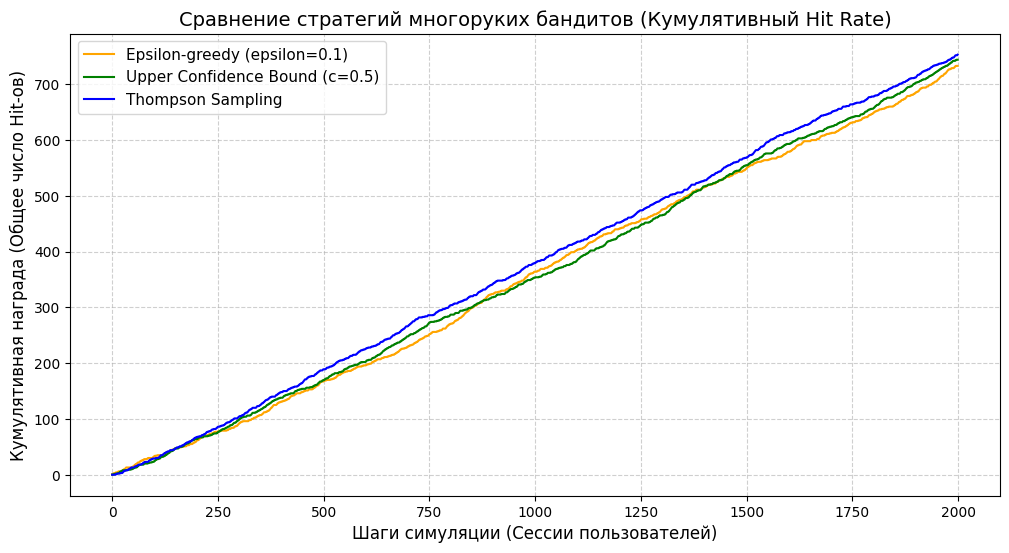

Распределение показов (выборов ручек) за время симуляции:


,Epsilon-Greedy,UCB1,Thompson Sampling
User-Based,1750,1924,1969
Item-Based,71,21,13
Hybrid,179,55,18


In [14]:
T = 2000
n_arms = 3
arm_names = ['User-Based', 'Item-Based', 'Hybrid']

def run_epsilon_greedy(epsilon=0.1):
    counts = np.zeros(n_arms)
    values = np.zeros(n_arms)
    rewards_history = []

    for t in range(T):
        user_idx = np.random.randint(0, len(sample_users))

        if np.random.rand() < epsilon:
            arm = np.random.randint(0, n_arms)
        else:
            arm = np.argmax(values)

        reward = precomputed_rewards[user_idx, arm]

        counts[arm] += 1
        values[arm] += (reward - values[arm]) / counts[arm]
        rewards_history.append(reward)

    return rewards_history, counts

def run_ucb1(c=1.0):
    counts = np.zeros(n_arms)
    values = np.zeros(n_arms)
    rewards_history = []

    for t in range(T):
        user_idx = np.random.randint(0, len(sample_users))

        if t < n_arms:
            arm = t
        else:
            ucb_values = values + c * np.sqrt(np.log(t) / counts)
            arm = np.argmax(ucb_values)

        reward = precomputed_rewards[user_idx, arm]

        counts[arm] += 1
        values[arm] += (reward - values[arm]) / counts[arm]
        rewards_history.append(reward)

    return rewards_history, counts

def run_thompson_sampling():
    alphas = np.ones(n_arms)
    betas = np.ones(n_arms)
    rewards_history = []
    counts = np.zeros(n_arms)

    for t in range(T):
        user_idx = np.random.randint(0, len(sample_users))

        sampled_values = [np.random.beta(alphas[arm], betas[arm]) for arm in range(n_arms)]
        arm = np.argmax(sampled_values)

        reward = precomputed_rewards[user_idx, arm]

        if reward == 1:
            alphas[arm] += 1
        else:
            betas[arm] += 1

        counts[arm] += 1
        rewards_history.append(reward)

    return rewards_history, counts

np.random.seed(42)
eg_rewards, eg_counts = run_epsilon_greedy(epsilon=0.1)
ucb_rewards, ucb_counts = run_ucb1(c=0.5)
ts_rewards, ts_counts = run_thompson_sampling()

plt.figure(figsize=(12, 6))
plt.plot(np.cumsum(eg_rewards), label='Epsilon-greedy (epsilon=0.1)', color='orange')
plt.plot(np.cumsum(ucb_rewards), label='Upper Confidence Bound (c=0.5)', color='green')
plt.plot(np.cumsum(ts_rewards), label='Thompson Sampling', color='blue')
plt.title('Сравнение стратегий многоруких бандитов (Кумулятивный Hit Rate)', fontsize=14)
plt.xlabel('Шаги симуляции (Сессии пользователей)', fontsize=12)
plt.ylabel('Кумулятивная награда (Общее число Hit-ов)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print('Распределение показов (выборов ручек) за время симуляции:')
df_stats = pd.DataFrame({
    'Epsilon-Greedy': eg_counts,
    'UCB1': ucb_counts,
    'Thompson Sampling': ts_counts
}, index=arm_names).astype(int)

display(df_stats)

#### Анализ результатов
1. **Истинные конверсии ручек**: На основе предрассчитанных оффлайн-метрик четко видно, что наилучшим выбирается `User-Based` подход, поэтому бандиты начали активно его эксплуатировать.
2. **Поведение стратегий**: видно, что `Thompson Sampling` метод быстрее сходится к оптимальной ручке, чем остальные.